<a href="https://colab.research.google.com/github/banteamlak1888/Floridan-University-Fundamentals-AI-Trianing/blob/main/Wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **STEP 1: INITIALIZE LIBRARIES**

In [ ]:
# STEP 1: INITIALIZE LIBRARIES
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

**STEP 2: LOAD DATASET**

In [ ]:
# STEP 2: LOAD DATASET
from google.colab import files
files.uploaded = files.upload()

Saving wine_unsupervised_full_dataset.csv to wine_unsupervised_full_dataset.csv


In [ ]:
# STEP 2: LOAD DATASET
data = pd.read_csv('wine_unsupervised_full_dataset.csv')
display(data.head())

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,wine_class_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [ ]:
data = pd.read_csv("wine_unsupervised_full_dataset.csv")

In [ ]:
print("First 5 rows:")
print(data.head())

print("\nDataset shape:")
print(data.shape)

print("\nColumns:")
print(data.columns.tolist())

First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target

**STEP 3: DATA INSPECTION**

In [ ]:
# STEP 3: DATA INSPECTION
print('Missing values per column:')
print(data.isnull().sum())
print('\nData types:')
print(data.dtypes)

Missing values per column:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
wine_class_name                 0
dtype: int64

Data types:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float

**STEP 4: SEPARATE FEATURES**

In [ ]:
# STEP 4: SEPARATE FEATURES
# Removing target labels for unsupervised learning
X = data.drop(['target', 'wine_class_name'], axis=1)
print(f'Feature matrix shape: {X.shape}')

Feature matrix shape: (178, 13)


**STEP 5: VISUALIZE DISTRIBUTIONS**

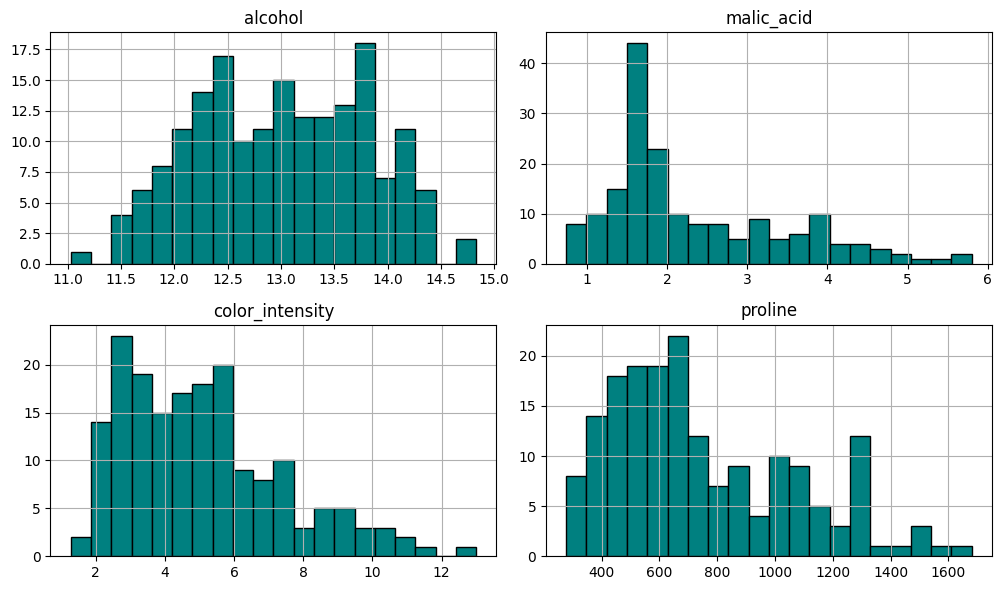

In [ ]:
# STEP 5: VISUALIZE DISTRIBUTIONS
selected_features = ['alcohol', 'malic_acid', 'color_intensity', 'proline']
X[selected_features].hist(figsize=(10, 6), bins=20, color='teal', edgecolor='black')
plt.tight_layout()
plt.show()

**STEP 6: FEATURE CORRELATION**

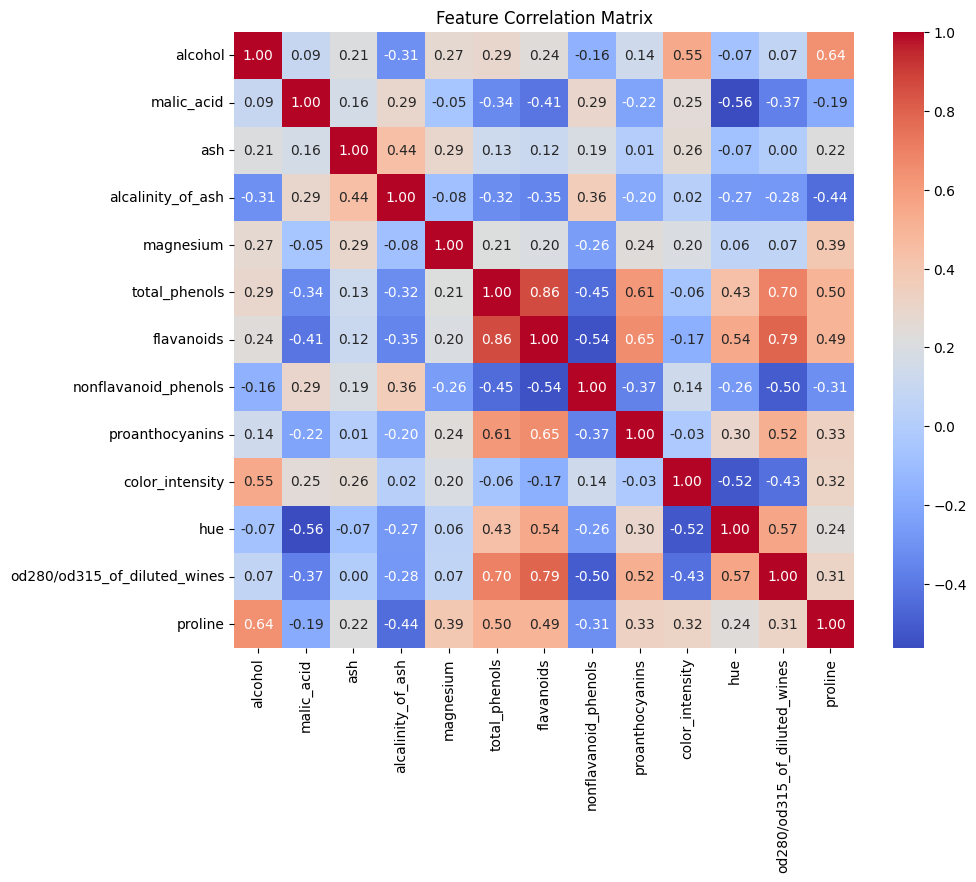

In [ ]:
# STEP 6: FEATURE CORRELATION
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

**STEP 10: FINAL K-MEANS MODEL**

In [ ]:
# STEP 10: FINAL K-MEANS MODEL
k_best = 3
kmeans_final = KMeans(n_clusters=k_best, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)
data['Cluster_Labels'] = clusters
print(f'Clustering complete with K={k_best}.')
print(data['Cluster_Labels'].value_counts())

Clustering complete with K=3.
Cluster_Labels
0    65
2    62
1    51
Name: count, dtype: int64


**STEP 11: VISUALIZING CLUSTERS WITH PCA**

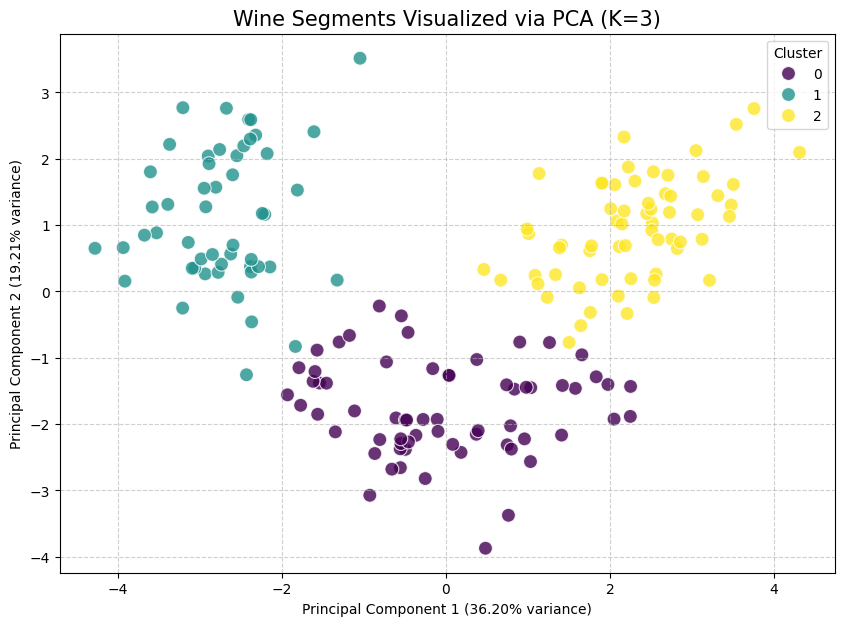

In [ ]:
# STEP 11: VISUALIZING CLUSTERS WITH PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', s=100, alpha=0.8)
plt.title(f'Wine Segments Visualized via PCA (K={k_best})')
plt.show()

**STEP 12: CLUSTER PROFILING**

In [ ]:
# STEP 12: CLUSTER PROFILING
cluster_profile = data.groupby('Cluster_Labels')[selected_features].mean()
display(cluster_profile)

Average feature values per cluster:


,alcohol,malic_acid,color_intensity,proline
Cluster_Labels,,,,
0,12.250923,1.897385,2.973077,510.169231
1,13.134118,3.307255,7.234706,619.058824
2,13.676774,1.997903,5.453548,1100.225806



Validation: Comparison with original wine classes:
Cluster_Labels    0   1   2
wine_class_name            
class_0           0   0  59
class_1          65   3   3
class_2           0  48   0


**STEP 17: SAVE THE FINAL CLUSTERED DATASET**

In [ ]:
# STEP 17: SAVE THE FINAL CLUSTERED DATASET
data.to_csv('wine_clustered_output.csv', index=False)
print("Clustered dataset saved successfully as 'wine_clustered_output.csv'.")

Clustered dataset saved successfully as 'wine_clustered_output.csv'.


**STEP 18: SHOW FINAL OUTPUT SAMPLE**

In [ ]:
# STEP 18: SHOW FINAL OUTPUT SAMPLE
display(data.head())

Final Clustered Dataset Sample:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,wine_class_name,Cluster_Labels,dbscan_cluster
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0,2,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0,2,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0,2,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0,2,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0,2,0
